# Stock Market Analysis – Returns & Volatility

## Introduction

This project focuses on the analysis of historical financial time series data in order to evaluate asset performance, returns, volatility and risks. Using daily price data, we perform a structured data cleaning process, compute key financial metrics, and visualize market behavior over time.

## Importing Libraries


In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use("seaborn-v0_8")


## Data Loading

In [196]:
df = pd.read_csv("data/sample_stock_data.csv")

## Exploratory Data Analysis


In [197]:
df.head()

,Date,Open,High,Low,Close,Volume
0,2020-01-01,137.454012,141.565146,98.427546,101.013118,8610
1,2020-01-02,195.071431,199.518558,160.237480,163.609605,2993
2,2020-01-03,173.199394,197.094145,169.176790,191.328695,1869
3,2020-01-06,159.865848,171.090755,159.353605,161.257347,2014
4,2020-01-07,115.601864,189.785872,110.636710,187.369859,1602


In [198]:
df.describe()

,Open,High,Low,Close,Volume
count,783.000000,783.000000,783.000000,783.000000,783.000000
mean,149.536682,171.952594,127.542661,149.994386,5352.556833
std,29.366542,23.817620,23.694677,29.155090,2577.957508
min,100.506158,105.672976,91.041662,100.001163,1002.000000
25%,123.985375,156.279914,107.946294,126.545449,3202.000000
50%,150.341727,176.268627,123.739745,149.625875,5251.000000
75%,175.287636,191.715877,143.793897,175.218386,7596.000000
max,199.971767,208.819120,194.955722,199.782086,9996.000000


In [199]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 783 entries, 0 to 782
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    783 non-null    str    
 1   Open    783 non-null    float64
 2   High    783 non-null    float64
 3   Low     783 non-null    float64
 4   Close   783 non-null    float64
 5   Volume  783 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 36.8 KB


## Data Cleaning and Preparation


In [200]:
# Convert date
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Sort values
df = df.sort_values("Date")

# Remove duplicates just in case
df = df.drop_duplicates(subset="Date")

# Set Date as index
df.set_index("Date", inplace=True)


## Price Evolution Analysis

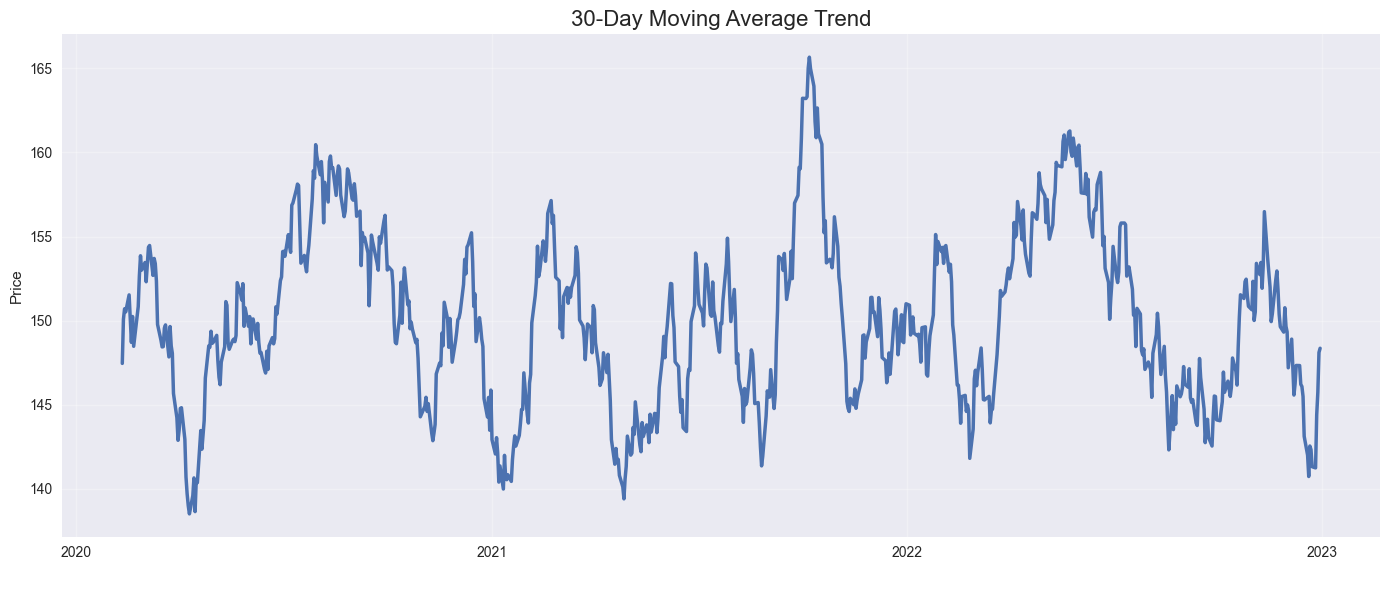

In [201]:
df["MA30"] = df["Close"].rolling(30).mean()

fig, ax = plt.subplots(figsize=(14,6))

ax.plot(df.index, df["MA30"], linewidth=2.5)

ax.set_title("30-Day Moving Average Trend", fontsize=16)
ax.set_xlabel(" ")
ax.set_ylabel("Price")

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Daily Returns

In [202]:
df["Return"] = df["Close"].pct_change()

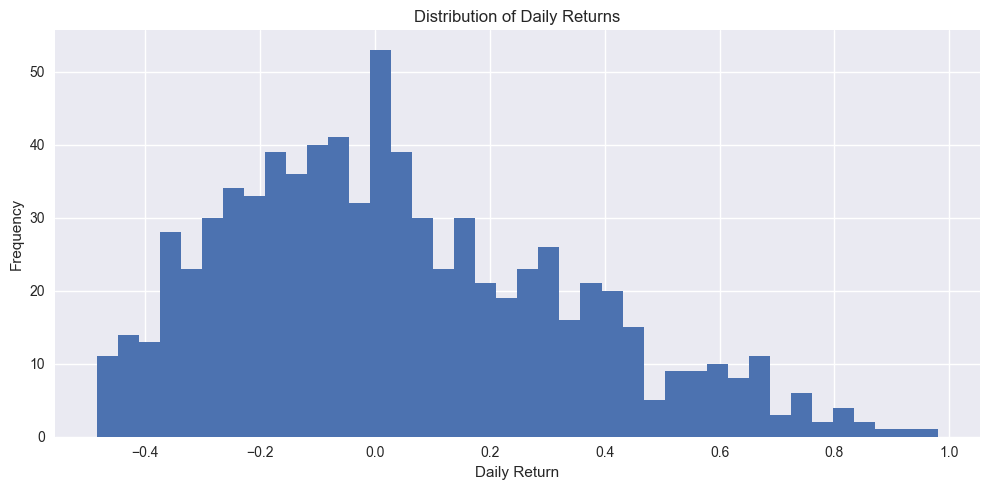

In [203]:
plt.figure(figsize=(10,5))

plt.hist(df["Return"].dropna(), bins=40)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()



## Volatility

In [204]:
volatility = df["Return"].std()
print("Historical Volatility:", volatility)


Historical Volatility: 0.2974843746534281


In [205]:
df["Rolling_Volatility"] = df["Return"].rolling(20).std()


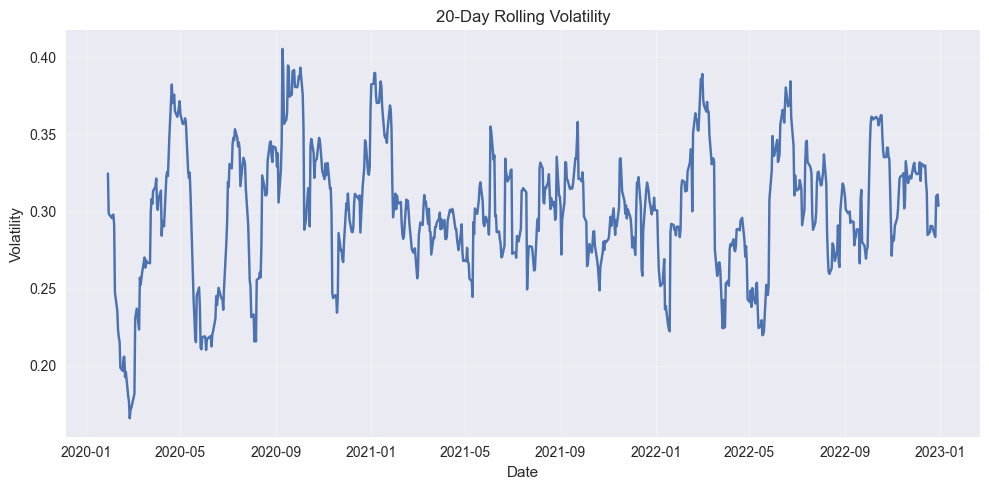

In [206]:
plt.figure(figsize=(10,5))
plt.plot(df.index, df["Rolling_Volatility"])

plt.title("20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



## Cumulative Return

In [207]:
df["Return"] = df["Close"].pct_change()
df["Cumulative"] = (1 + df["Return"]).cumprod()
df["Cumulative_Smooth"] = df["Cumulative"].rolling(5).mean()


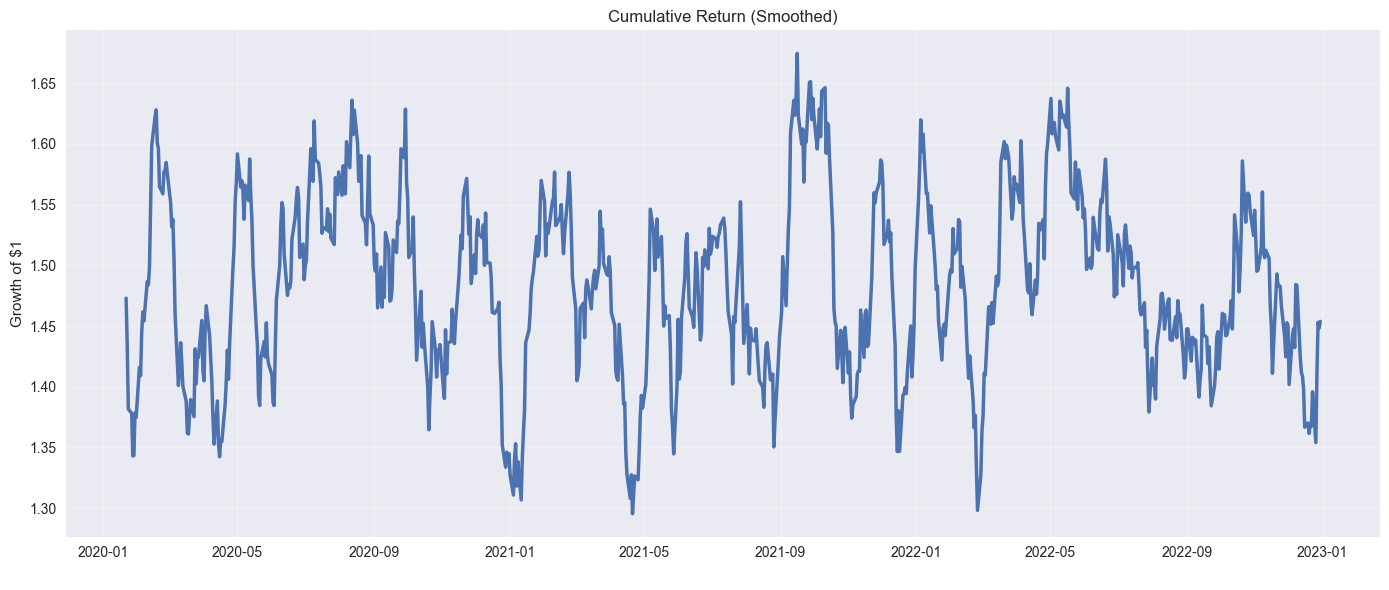

In [208]:
df["Cumulative"] = (1 + df["Return"]).cumprod()

# Smooth cumulative curve slightly
df["Cumulative_Smooth"] = df["Cumulative"].rolling(15).mean()

plt.figure(figsize=(14,6))
plt.plot(df.index, df["Cumulative_Smooth"], linewidth=2.5)

plt.title("Cumulative Return (Smoothed)")
plt.xlabel(" ")
plt.ylabel("Growth of $1")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



## Key Metrics to Report

In [209]:
mean_return = df["Return"].mean()
max_return = df["Return"].max()
min_return = df["Return"].min()

In [210]:
mean_return_annual = mean_return * 252
volatility_annual = volatility * np.sqrt(252)

In [211]:
sharpe_ratio = mean_return_annual / volatility_annual


In [212]:
print("Mean Daily Return:", round(mean_return, 3))
print("Annualized Return:", round(mean_return_annual * 100, 2), "%")
print("Annualized Volatility:", round(volatility_annual * 100, 2), "%")
print("Max Daily Return:", round(max_return * 100, 2), "%")
print("Min Daily Return:", round(min_return * 100, 2), "%")
print("Sharpe Ratio:", round(sharpe_ratio, 2))


Mean Daily Return: 0.042
Annualized Return: 1053.78 %
Annualized Volatility: 472.24 %
Max Daily Return: 98.03 %
Min Daily Return: -48.46 %
Sharpe Ratio: 2.23


In [213]:
skewness = df["Return"].skew()
kurtosis = df["Return"].kurt()

print(f"Skewness: {skewness:.2f}")
print(f"Kurtosis: {kurtosis:.2f}")





Skewness: 0.57
Kurtosis: -0.22


## 📊 General Conclusions

### 1️⃣ Return Behavior

- The asset shows a positive average daily return.

- The return distribution exhibits moderate positive skewness (0.57).

- This suggests occasional large positive returns.

- There is no strong evidence of frequent extreme crashes.

### 2️⃣ Risk Profile

Annualized volatility indicates a high-risk asset.

- However, excess kurtosis (-0.22) suggests that the distribution is approximately close to normal.

- Extreme events exist but do not dominate the distribution.

### 3️⃣ Performance Metrics

- The Sharpe Ratio (~2.23) indicates strong risk-adjusted performance.

- However, unusually large daily returns (near ±50% to 100%) suggest potential data anomalies or structural price changes.

- Further data validation may be required.

4️⃣ Investment Interpretation

- The asset appears to offer high returns accompanied by high volatility.

- Positive skewness implies upside potential.

- Risk-adjusted metrics suggest strong performance, but extreme daily movements should be investigated before drawing firm conclusions.

### 📌 Final Assessment

Overall, the asset demonstrates:

- Positive growth potential

- Moderate asymmetry toward gains

- Volatility consistent with speculative or high-growth assets





